# Damage growth and transport on a floating ice shelf

This experiment couples the van der Veen (VdV) stress-intensity calculation and Freund crack-growth law in `damage_law.tex` to **Icepack's two-dimensional shelf-flow model**. Separate surface and basal crack fractions grow, travel with the ice, and weaken the viscosity. All fields and forcing are synthetic; no observations are fitted.

A passive marker starts in the same location as an imposed basal-flaw patch. Its displacement identifies transport independently of new fracture. The predicted quantities are surface and basal crevasse depth, their propagation thresholds, and the spatial history of the fractured thickness fraction.

## Mechanics and boundary conditions

Let $D_s=d_s/H$, $D_b=d_b/H$, and $D=D_s+D_b$. The model advances

$$\partial_t D_j+\mathbf u\cdot\nabla D_j
=\frac{v_j}{H}\mathcal F(K_{\mathrm I}^j/K_{\mathrm{Ic}}),\qquad
\mathcal F(q)=\begin{cases}0,&q<1,\\1-q^{-2},&q\ge1.\end{cases}$$

The stationary-crack stress intensities are evaluated from the finite-slab weight functions in the accompanying note, **not from the reduced zero-stress approximation**. Fractions follow affine vertical stretching of the column; propagation is relative to that stretching. Both crack families have a fixed normal $(1,0)$, so the opening stress is the bulk membrane component $R_n=M_{xx}=2\tau_{xx}+\tau_{yy}$. Crack rotation and interactions are omitted.

| Quantity | Specification |
|---|---|
| Domain | $0<x<40$ km, $0<y<20$ km; horizontal, floating shelf |
| Initial thickness | $H=400-100x/(40\ \mathrm{km})$ m |
| Inflow, $x=0$ | $u_x=800\sin^2(\pi y/20\ \mathrm{km})$ m/yr, $u_y=0$, $H=400$ m |
| Lateral walls | $\mathbf u=0$ at $y=0,20$ km |
| Ocean front | Hydrostatic seawater traction at fixed $x=40$ km; ice and damage can leave |
| Mass balance | Zero accumulation and zero surface/basal melting; $\partial_t H+\nabla\cdot(H\mathbf u)=0$ |
| Surface water | Dry cracks |
| Basal water | Ocean connection: mouth pressure $p_b^0=\rho_i gH$, hydrostatic seawater in the crack |
| Material | $T=263.15$ K, Glen exponent 3, $K_{\mathrm{Ic}}=0.1$ MPa $\sqrt{\mathrm m}$ |
| Initial flaws | $D_s=0.01$; $D_b=0.01+0.06\exp[-((x-8\ \mathrm{km})/2\ \mathrm{km})^2-((y-10\ \mathrm{km})/3\ \mathrm{km})^2]$ |
| Advected inflow | $D_s=D_b=0.01$; passive marker zero |
| Crack-speed scales | $v_s=v_b=5$ m/yr, illustrative effective speeds, **not Rayleigh speeds or measured parameters** |

Damage weakens the shelf through $A_D=A(T)(1-D)^{-3}$, the closure used in Icepack's damage example. Equivalently, we multiply the undamaged viscous action by $(1-D)$. The stress supplied to VdV uses this same bulk rheology. Identifying geometric penetration with isotropic rheological damage is an additional modeling assumption. No extra ligament-stress amplification is applied inside VdV.

The calculation stops at the first $D_s+D_b=1$ event, before another momentum solve. There is no calving or continuation with an arbitrary damage cap. The default experiment is intended to examine the preceding growth and transport.

## Numerical calculation

`vdv.py` evaluates the crack integrals in SI units. Substituting $y/a=\sin\theta$ removes the integrable tip singularity; waterline intervals are integrated separately with 32-point Gauss quadrature. The local source is integrated with adaptive RK23 and an event at full-thickness connection, recomputing both stress intensities at every stage.

`ice_shelf.py` uses Icepack for momentum, thickness, and damage advection. Velocity uses continuous quadratic elements, thickness continuous linear elements, and damage one constant per triangular cell (DG0). The existing damage solver advances advection with SSPRK3; its original fracture/healing source is replaced by zero while the VdV source is integrated separately. The source, transport/thickness, and momentum updates are split at first order. Stress and thickness are held fixed during each local reaction solve. A cell-inflow Courant bound of 0.5 controls advection; no physical rate is tuned to the timestep. DG0 introduces numerical spreading, tested below and in `test_ice_shelf.py`.

The mesh has $40\times20$ rectangles split into 1,600 triangles. The maximum flow step is 0.25 yr. Icepack uses MPa–m–yr; membrane stress is multiplied by $10^6$ before calling VdV, and time and speed are converted explicitly to SI. Densities are 917 kg/m³ for ice and 1,024 kg/m³ for seawater.

In [1]:
from pathlib import Path
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import FuncFormatter
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
import firedrake as fd
from firedrake.pyplot import tripcolor, tricontour
from scipy.optimize import brentq
from ice_shelf import run_shelf
from vdv import stress_intensities, advance_damage, YEAR, RHO_I, G

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
figures = Path('figures')
figures.mkdir(exist_ok=True)

/home/firedrake/firedrake/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Before the spatial experiment, check that a dry surface crack approaches the stable LEFM arrest depth under fixed forcing. This is a numerical verification, not a comparison with a measured crevasse.

In [2]:
H, R, Kc = 400.0, 150e3, 1e5
root = brentq(lambda d: stress_intensities(d, .01, H, R, 0)[0]-Kc, .01, .2)
s, b, _, failed = advance_damage(.01, .01, H, R, 0, 20*YEAR,
                                20/YEAR, 0, rtol=1e-8, atol=1e-11)
assert not failed and abs(s-root) < 2e-6
print(f'LEFM arrest depth: {H*root:.5f} m; integrated depth: {H*s:.5f} m')

LEFM arrest depth: 25.05760 m; integrated depth: 25.05760 m


In [3]:
start = perf_counter()
result = run_shelf(progress=True)
frames, history = result['snapshots'], result['history']
print(f'Elapsed computation: {perf_counter()-start:.1f} s')
print(f'Maximum Courant number: {result["max_courant"]:.3f}')
print(f'Full-thickness failure: {result["failed"]}')
print(f'Final mean D_s={history[-1,1]:.4f}, D_b={history[-1,2]:.4f}; '
      f'maximum D={history[-1,3]:.4f}')
print(f'Passive patch centroid: {history[0,5]/1000:.2f} -> {history[-1,5]/1000:.2f} km')
assert history[-1,0] == 30 and not result['failed']
assert history[-1,2] > history[0,2] and history[-1,5] > history[0,5]

t=  1.0 yr, max D=0.076, mean H=352.9 m


t=  2.0 yr, max D=0.085, mean H=355.7 m


t=  3.0 yr, max D=0.118, mean H=358.5 m


t=  4.0 yr, max D=0.149, mean H=361.1 m


t=  5.0 yr, max D=0.171, mean H=363.7 m


...

t= 27.0 yr, max D=0.550, mean H=412.8 m


t= 28.0 yr, max D=0.567, mean H=414.8 m


t= 29.0 yr, max D=0.583, mean H=416.8 m


t= 30.0 yr, max D=0.599, mean H=418.8 m


Elapsed computation: 181.1 s
Maximum Courant number: 0.397
Full-thickness failure: False
Final mean D_s=0.0183, D_b=0.0774; maximum D=0.5991
Passive patch centroid: 8.00 -> 17.01 km


## Growth and downstream transport

The next figure shows total fractured thickness fraction at four times. White contours enclose half the passive marker's instantaneous maximum; they locate the transported initial patch and do not mark a fracture threshold. Each panel uses the same color scale. The flow responds to both thickness changes and accumulated damage.

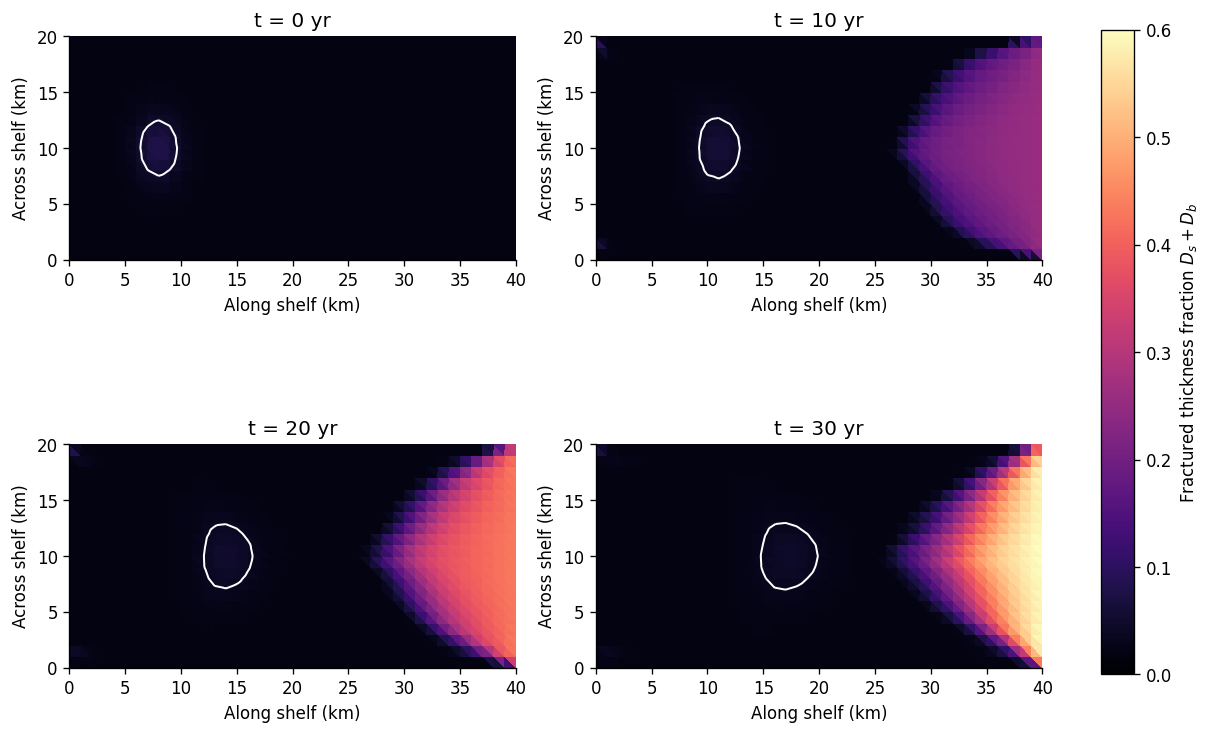

In [4]:
def plan_axes(ax):
    ax.set(xlim=(0, 40000), ylim=(0, 20000), aspect='equal',
           xlabel='Along shelf (km)', ylabel='Across shelf (km)')
    ax.xaxis.set_major_formatter(FuncFormatter(lambda value, pos: f'{value/1000:g}'))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, pos: f'{value/1000:g}'))

def total_damage(frame):
    return fd.Function(frame['ds'].function_space()).assign(frame['ds']+frame['db'])

dmax = np.ceil(max((f['ds'].dat.data_ro+f['db'].dat.data_ro).max()
                   for f in frames)*20)/20
fig, axes = plt.subplots(2, 2, figsize=(10, 6.8), layout='constrained')
for ax, frame in zip(axes.flat, [frames[i] for i in (0, 10, 20, 30)]):
    colors = tripcolor(total_damage(frame), axes=ax, cmap='magma', vmin=0, vmax=dmax)
    # Continuous projection is used only for drawing the marker contour.
    marker = fd.Function(fd.FunctionSpace(result['mesh'], 'CG', 1)).project(frame['marker'])
    tricontour(marker, levels=[.5*marker.dat.data_ro.max()], colors='white',
               linewidths=1.2, axes=ax)
    plan_axes(ax)
    ax.set_title(f't = {frame["time"]:.0f} yr')
fig.colorbar(colors, ax=axes, label='Fractured thickness fraction $D_s+D_b$', shrink=.8)
fig.savefig(figures/'shelf_damage.png', dpi=180)
plt.show()

**Figure 1.** Plan-view total damage over 30 years, with the transported initial-patch marker in white. The shelf receives small pre-existing flaws at the upstream boundary. VdV propagation increases damage only where the relevant stress intensity exceeds toughness. Declines at a fixed location can result from advection; the local source contains no healing.

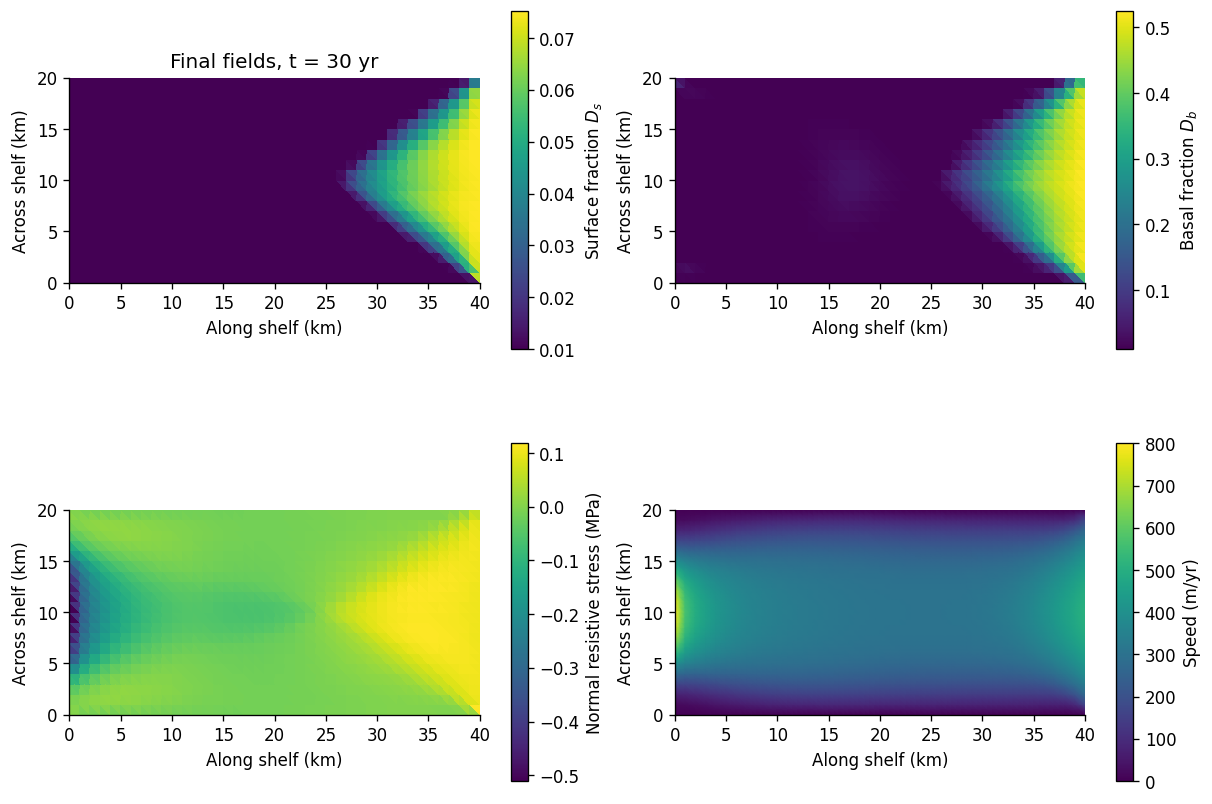

In [5]:
last = frames[-1]
fig, axes = plt.subplots(2, 2, figsize=(10, 7.2), layout='constrained')
fields = [last['ds'], last['db'], last['stress'],
          fd.Function(fd.FunctionSpace(result['mesh'], 'CG', 1)).interpolate(
              fd.sqrt(fd.inner(last['velocity'], last['velocity'])))]
labels = ['Surface fraction $D_s$', 'Basal fraction $D_b$',
          'Normal resistive stress (MPa)', 'Speed (m/yr)']
for ax, field, label in zip(axes.flat, fields, labels):
    color = tripcolor(field, axes=ax, cmap='viridis')
    fig.colorbar(color, ax=ax, label=label, shrink=.8)
    plan_axes(ax)
axes[0,0].set_title(f'Final fields, t = {last["time"]:.0f} yr')
fig.savefig(figures/'shelf_fields.png', dpi=180)
plt.show()

**Figure 2.** Final surface and basal damage, bulk normal resistive stress, and shelf speed. The surface and basal stress intensities differ because ice overburden closes surface cracks while seawater supports basal cracks. The velocity and stress come from the two-dimensional momentum solve, with damage-dependent viscosity; they are not prescribed interior fields.

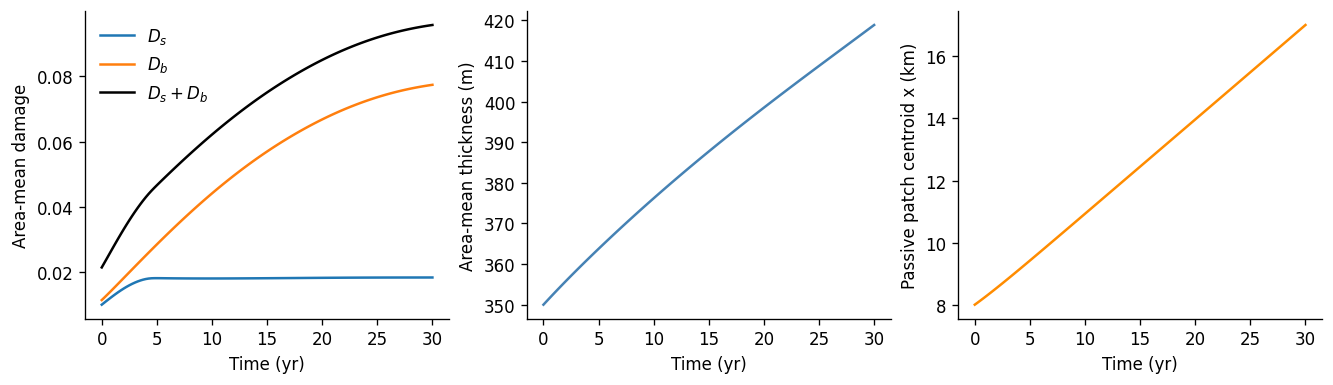

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1), layout='constrained')
axes[0].plot(history[:,0], history[:,1], label='$D_s$')
axes[0].plot(history[:,0], history[:,2], label='$D_b$')
axes[0].plot(history[:,0], history[:,1]+history[:,2], label='$D_s+D_b$', color='black')
axes[0].set(ylabel='Area-mean damage')
axes[0].legend(frameon=False)
axes[1].plot(history[:,0], history[:,4], color='steelblue')
axes[1].set(ylabel='Area-mean thickness (m)')
axes[2].plot(history[:,0], history[:,5]/1000, color='darkorange')
axes[2].set(ylabel='Passive patch centroid x (km)')
for ax in axes:
    ax.set_xlabel('Time (yr)')
fig.savefig(figures/'shelf_history.png', dpi=180)
plt.show()

**Figure 3.** Area-mean damage, mean thickness, and passive-marker centroid. The mean-damage change includes the source and boundary transport. Thickness evolves by mass continuity with zero accumulation and melting. The marker centroid measures transport on the part of the patch remaining in the domain.

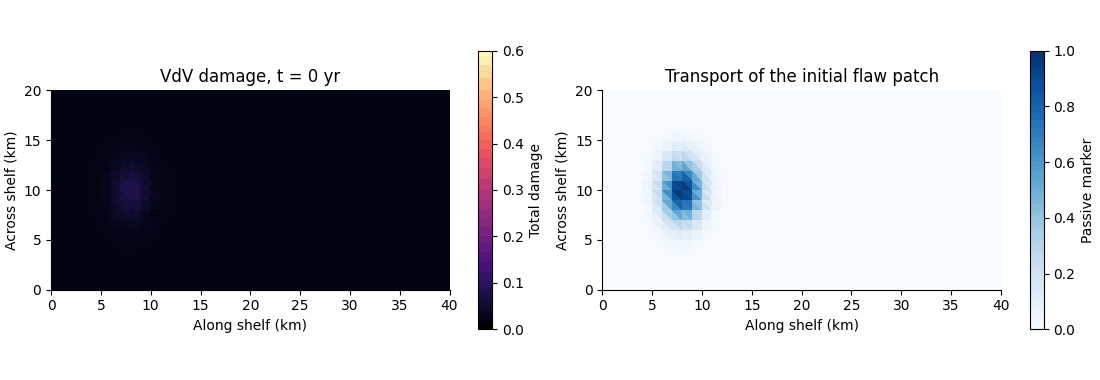

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout='constrained')
for ax, cmap, upper, label in zip(axes, ['magma', 'Blues'], [dmax, 1],
                                ['Total damage', 'Passive marker']):
    fig.colorbar(ScalarMappable(norm=Normalize(0, upper), cmap=cmap),
                 ax=ax, label=label, shrink=.75)

def draw(index):
    frame = frames[index]
    for ax in axes:
        ax.clear()
    tripcolor(total_damage(frame), axes=axes[0], cmap='magma', vmin=0, vmax=dmax)
    tripcolor(frame['marker'], axes=axes[1], cmap='Blues', vmin=0, vmax=1)
    for ax in axes:
        plan_axes(ax)
    axes[0].set_title(f'VdV damage, t = {frame["time"]:.0f} yr')
    axes[1].set_title('Transport of the initial flaw patch')
    return []

animation = FuncAnimation(fig, draw, frames=len(frames), interval=160, blit=False)
animation.save(figures/'shelf_evolution.gif', writer=PillowWriter(fps=6), dpi=100)
plt.close(fig)
display(Image(filename=str(figures/'shelf_evolution.gif')))

## Resolution check and interpretation

The following calculation compares the first five years with half the maximum timestep, on the same mesh, and with a coarser $20\times10$ mesh. It reports the damage differences rather than treating a visually plausible pattern as verification. The separate automated tests compare passive DG0 transport with an exact translated field, check the crack integrals against adaptive quadrature, and verify LEFM arrest and terminal failure-time convergence.

In [8]:
coarse = run_shelf(nx=20, ny=10, final_time=5, snapshot_interval=5)
fine_time = run_shelf(final_time=5, dt=.125, snapshot_interval=5)
base = frames[5]
area_mean = lambda frame: fd.assemble(total_damage(frame)*fd.dx)/(40e3*20e3)
means = [float(area_mean(f)) for f in [coarse['snapshots'][-1], base, fine_time['snapshots'][-1]]]
# These are independent meshes with identical serial construction, so compare
# the DG0 cell arrays for the same-mesh time-step check.
base_values = base['ds'].dat.data_ro+base['db'].dat.data_ro
fine_values = fine_time['snapshots'][-1]['ds'].dat.data_ro+fine_time['snapshots'][-1]['db'].dat.data_ro
centers = lambda frame: fd.Function(fd.VectorFunctionSpace(frame['ds'].function_space().mesh(), 'DG', 0)).interpolate(
    fd.SpatialCoordinate(frame['ds'].function_space().mesh())).dat.data_ro
np.testing.assert_allclose(centers(base), centers(fine_time['snapshots'][-1]))
rms_time = np.sqrt(np.mean((base_values-fine_values)**2))
print('Five-year mean D:')
print(f'  20 x 10 mesh, dt <= 0.25 yr: {means[0]:.7f}')
print(f'  40 x 20 mesh, dt <= 0.25 yr: {means[1]:.7f}')
print(f'  40 x 20 mesh, dt <= 0.125 yr: {means[2]:.7f}')
print(f'RMS damage change on halving dt: {rms_time:.3e}')
print(f'Mean damage change on refining mesh: {abs(means[0]-means[1]):.3e}')
assert rms_time < .002

Five-year mean D:
  20 x 10 mesh, dt <= 0.25 yr: 0.0461703
  40 x 20 mesh, dt <= 0.25 yr: 0.0465908
  40 x 20 mesh, dt <= 0.125 yr: 0.0466147
RMS damage change on halving dt: 9.667e-05
Mean damage change on refining mesh: 4.206e-04


The experiment predicts how finite crevasses grow and travel under specified water-pressure conditions. Time-resolved crevasse depths could test the relation $H\mathcal D_tD_j/\mathcal F(K_{\mathrm I}^j/K_{\mathrm{Ic}})=v_j$ where $K_{\mathrm I}^j>K_{\mathrm{Ic}}$. The terminal event would predict through-thickness connection, not an iceberg's detachment or trajectory.

The effective 5 m/yr speed is deliberately an uncalibrated parameter of this toy experiment. Replacing it by a Rayleigh speed changes the physical timescale and requires resolving a fracture event; the multiyear pictures should not be interpreted as an elastodynamic prediction. Other limitations are isolated edge-crack mechanics, a fixed crack normal, prescribed basal water connection, isotropic viscosity weakening, and DG0 numerical spreading. The initial thickness is not assumed to be steady. The five-year checks above do not establish convergence of a long-term calving forecast.

Model equations and sources: [technical note](damage_law.pdf); [Icepack damage solver](https://github.com/icepack/icepack/blob/c9a29780cd0f7d068d206cb5a170fa367a7655b0/src/icepack/solvers/damage_solver.py); [Icepack shelf example](https://github.com/icepack/icepack/blob/c9a29780cd0f7d068d206cb5a170fa367a7655b0/notebooks/tutorials/02-synthetic-ice-shelf.ipynb). See the README for the pinned Docker environment and execution commands.